In [ ]:
# Q8
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


In [25]:
df = pd.read_csv('/Users/kushbajpai/Downloads/Datasets/8_mnist_train.csv')
df = df.sample(random_state=10, frac=0.1)
df

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
4883,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
28477,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8527,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
38347,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3363,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44647,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
45900,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20033,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41204,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=12, stratify=y
)

In [28]:
model = GaussianMixture(n_components=10, random_state=2)
model.fit(X_train)

,"n_components n_components: int, default=1The number of mixture components.",10
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",2


In [29]:
train_clusters = model.predict(X_train)
test_clusters = model.predict(X_test)

In [30]:
cm = confusion_matrix(y_train, train_clusters)

labels = np.argmax(cm, axis=0)

y_pred = labels[test_clusters]

Accuracy: 0.365


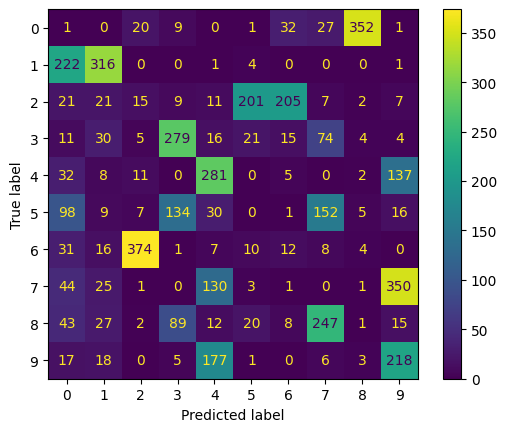

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay(cm).plot()